<a href="https://colab.research.google.com/github/mariacastrom00/AI_exercises_MJCM/blob/main/assignment3_AH2179_MJCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3 - Reveal the most representative day-types
By: Maria José Castro Moreno
Subject: AH2179

# Importing data, vectorizing

In [1]:
import pandas as pd
import numpy as np

# Dataset from Canvas
data_df = pd.read_csv("dataset_exercise_5_clustering_highway_traffic.csv",sep=";")
data_df

,PORTAL,Date,time_from,time_to,Interval_5,SPEED_MS_AVG,flow
0,"E4S 56,780",20210101,00:00:00,00:05:00,0,18.56,39
1,"E4S 56,780",20210101,00:05:00,00:10:00,1,20.39,18
2,"E4S 56,780",20210101,00:10:00,00:15:00,2,19.27,26
3,"E4S 56,780",20210101,00:15:00,00:20:00,3,19.52,52
4,"E4S 56,780",20210101,00:20:00,00:25:00,4,20.52,52
...,...,...,...,...,...,...,...
104838,"E4S 56,780",20211231,23:35:00,23:40:00,283,19.58,115
104839,"E4S 56,780",20211231,23:40:00,23:45:00,284,19.47,87
104840,"E4S 56,780",20211231,23:45:00,23:50:00,285,19.77,130
104841,"E4S 56,780",20211231,23:50:00,23:55:00,286,18.79,129


In [2]:
# Forming the unique days and number of 5-minute intervals per day
data_df.sort_values(["Date", "Interval_5"])
days = np.unique(data_df[['Date']].values.ravel())
ndays = len(days)

# Defining the total number of 5-minute intervals in a day
nintvals = 288

# Grouping DataFrame 'data_df' by the "Date" column
day_subsets_df = data_df.groupby(["Date"])

# Creating a matrix "vectorized_day_dataset" filled with nan values
vectorized_day_dataset = np.zeros((ndays, nintvals))
vectorized_day_dataset.fill(np.nan)

# Looping through each unique day
for i in range(0, ndays):
    df_t = day_subsets_df.get_group(days[i]) # Get the DataFrame corresponding to the current day

    # Looping through each row in the current days DataFrame
    for j in range(len(df_t)):
        # Get the current day's DataFrame
        df_t = day_subsets_df.get_group(days[i])

        # Extracting the "Interval_5" and "flow" values and filling the "vectorized_day_dataset"
        vectorized_day_dataset[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

print(vectorized_day_dataset)

/tmp/ipykernel_43152/2954020483.py:20: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])
/tmp/ipykernel_43152/2954020483.py:25: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])


[[ 39.  18.  26. ...  32.  39.  34.]
 [ 30.  32.  27. ...  44.  41.  39.]
 [ 36.  44.  52. ...  50.  45.  23.]
 ...
 [ 20.  34.  31. ...  38.  42.  36.]
 [ 36.  40.  25. ...  38.  56.  35.]
 [ 33.  32.  34. ... 130. 129. 117.]]


# Data exploration

In [3]:
print('number of nans',np.sum(np.isnan(vectorized_day_dataset)))
print('rate of nans',np.sum(np.isnan(vectorized_day_dataset))/(ndays*nintvals))

number of nans 277
rate of nans 0.0026350837138508373


Number of days with missing value 28


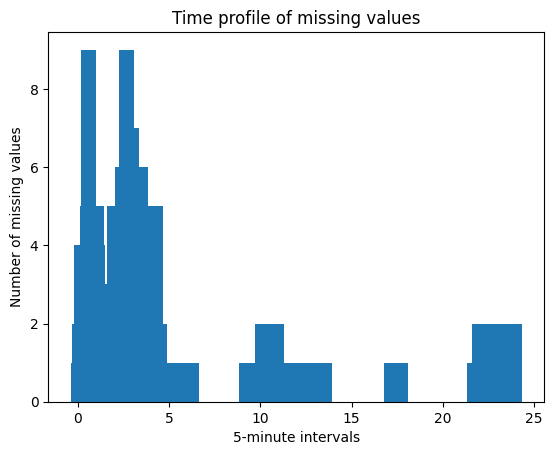

In [4]:
import matplotlib.pyplot as plt

nans_per_time = np.sum(np.isnan(vectorized_day_dataset),0)
nans_per_day = np.sum(np.isnan(vectorized_day_dataset),1)
#print(nans_per_time.shape)

print('Number of days with missing value',np.size(np.where(nans_per_day > 0),1))

fig, ax = plt.subplots()
x_axis = np.arange(0, nintvals, 1, dtype=int)
x_axis_hours = []
for i in range(0, len(x_axis)):
  x_axis_hours.append(float(x_axis[i]*5)/60)
ax.bar(x_axis_hours,height=nans_per_time)


ax.set_ylabel('Number of missing values')
ax.set_xlabel('5-minute intervals')
ax.set_title('Time profile of missing values')

plt.show()

## Daily profile of flow dynamic

Visualization of traffic flow across time of day to detect if there is a specific traffic pattern.

The curves are then used for the clustering algorithms.

Peaks or irregularities correspond to: Commute to and from work, freight transport, evening leasure.

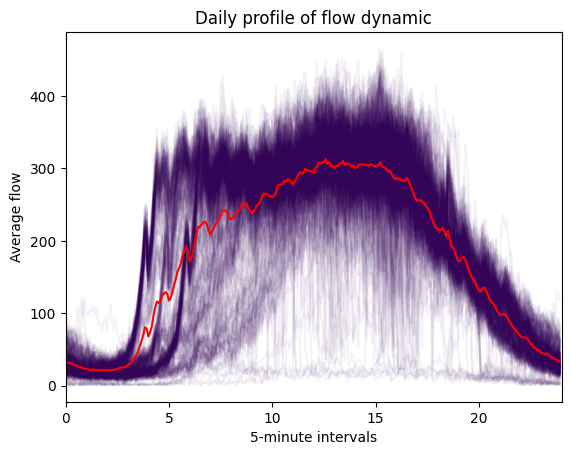

In [5]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()# a convenient way to create a new figure and a set of subplots.

# Above line plots the dataset with specified color and transparency.
ax.plot(np.array([x_axis_hours,]*ndays).transpose(),vectorized_day_dataset.transpose(),color='#340459',alpha=0.05)

# Above line plots the average of the dataset in black color.
ax.plot(x_axis_hours,np.transpose(np.nanmean(vectorized_day_dataset,0)),color='red')

ax.set_ylabel('Average flow')
ax.set_xlabel('5-minute intervals')
plt.xlim(0,24)
ax.set_title('Daily profile of flow dynamic')

plt.show()

Boxplot to compress data with 5 minute interval - Average, spread and outliers can be observed

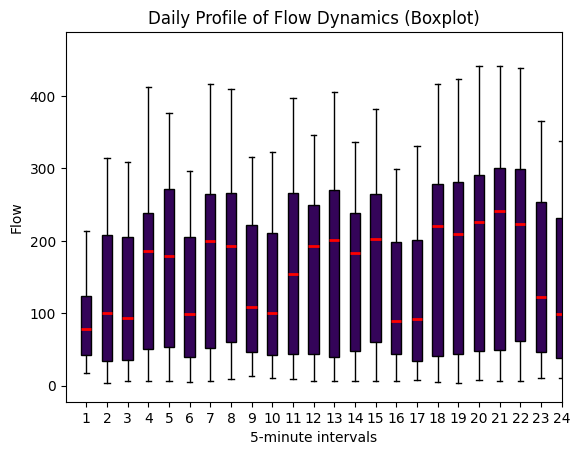

In [6]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()  # This line is a convenient way to create a new figure and a set of subplots.

# Create a boxplot for the dataset
boxplot = ax.boxplot(vectorized_day_dataset.T, patch_artist=True)

# Customize the boxplot appearance
for patch in boxplot['boxes']:
    patch.set_facecolor('#340459')  # Set the box color to gray
for median in boxplot['medians']:
    median.set(color='red', linewidth=2)  # Set median line color to black

# Set the y-axis label
ax.set_ylabel('Flow')

# Set the x-axis label
ax.set_xlabel('5-minute intervals')

# Set the x-axis limits to be between 0 and 24
plt.xlim(0, 24)

# Set the title of the plot
ax.set_title('Daily Profile of Flow Dynamics (Boxplot)')

# Display the plot
plt.show()

Day of the week to divide and see if there is any difference between weekdays and weekends. Machine learning to cluster and see if the pattern is according to "human sense"

In [7]:
import datetime

# Create an array 'day_of_week' to store the day of the week for each unique date
day_of_week = np.zeros((ndays))

# Loop through each unique date
for i in range(0, ndays):
    # Parse the current date from a string to a datetime object
    day_dt = datetime.datetime.strptime(str(days[i]), '%Y%m%d')

    # Get the day of the week (1 for Monday, 2 for Tuesday, ..., 7 for Sunday)
    day_of_week[i] = day_dt.isoweekday()

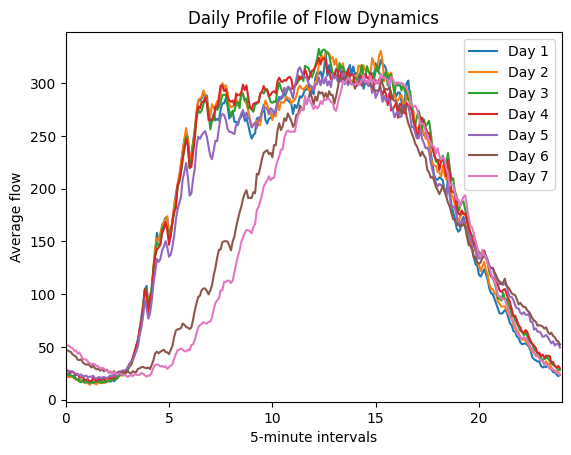

In [8]:
# Create a new figure and axis object using subplots
fig, ax = plt.subplots()

# Iterate through each day of the week (from 1 to 7)
for i in range(1, 8):
    # Find the indices of days that correspond to the current day of the week
    day_of_week_index_t = np.where(day_of_week == i)

    # Calculate the number of days that match the current day of the week
    ndays_t = np.size(day_of_week_index_t[0])

    # Plot the average flow for the current day of the week
    ax.plot(x_axis_hours,
            np.nanmean(vectorized_day_dataset[day_of_week_index_t[0], :].transpose(), 1),
            label= 'Day ' + str(i))
    # This line plots the average flow for the current day of the week.
    # 'np.nanmean()' calculates the mean while handling NaN values.

# y- and x-axis
ax.set_ylabel('Average flow')
ax.set_xlabel('5-minute intervals')

# x-axis limits to be between 0 and 24
plt.xlim(0, 24)

ax.set_title('Daily Profile of Flow Dynamics')
ax.legend()
plt.show()

As seen above, saturdays (day 6) and sundays (day 7) show a different pattern that the weekdays.

## Other types of visualizations

The following visualizations are not presented in the exercises but I wanted to see other ways to visualize the data.

Sample behavior, spot outliers, and visualize patterns.

Material that I read:
https://chartgen.ai/resources/blog/heatmap-data-visualization-complete-guide-examples

https://machinelearningmastery.com/principal-component-analysis-for-visualization/


### Heatmap for daily profiles

Another way to visualize recurring patterns, difference between weekday and weekends, seasonal changes.

Patterns in this visualization MAY correspond to clusters. For example the horizontal patters that repeat themselves during different days, days with low flow or unusual patterns.

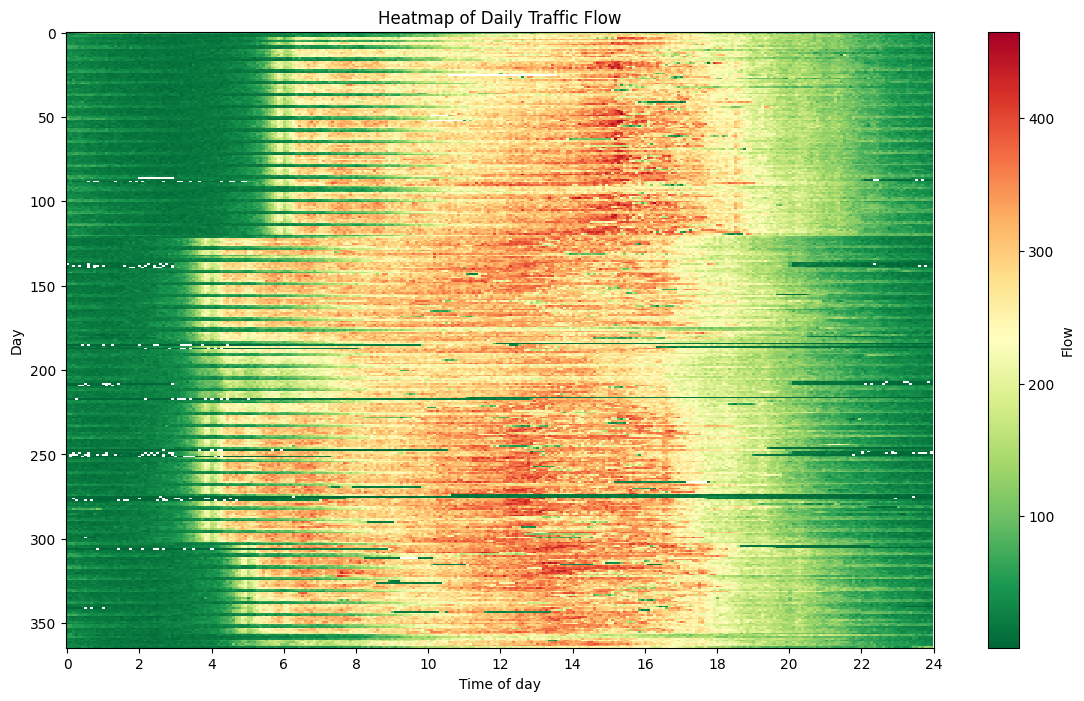

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(
    vectorized_day_dataset,
    aspect='auto',
    interpolation='none',
    cmap='RdYlGn_r')

ax.set_xlabel('Time of day')
ax.set_ylabel('Day')
ax.set_title('Heatmap of Daily Traffic Flow')

# x-axis from 5-minute intervals to hours
intervals_per_hour = 12
hours = np.arange(0, 25, 2)
ticks = hours * intervals_per_hour

ax.set_xticks(ticks)
ax.set_xticklabels(hours)

plt.colorbar(im, ax=ax, label='Flow')

plt.show()

### Daily PCA (Principal Component Analysis) plot

Vizualization to see possible clustering. Before: 288 variables for every profile (measurements every 5 minutes). PCA: From 288 to 2 dimenstions. One point, one day.

PCA shows if there is points are naturally concentrated close to which ones and also if they are related to a specific day of the week.

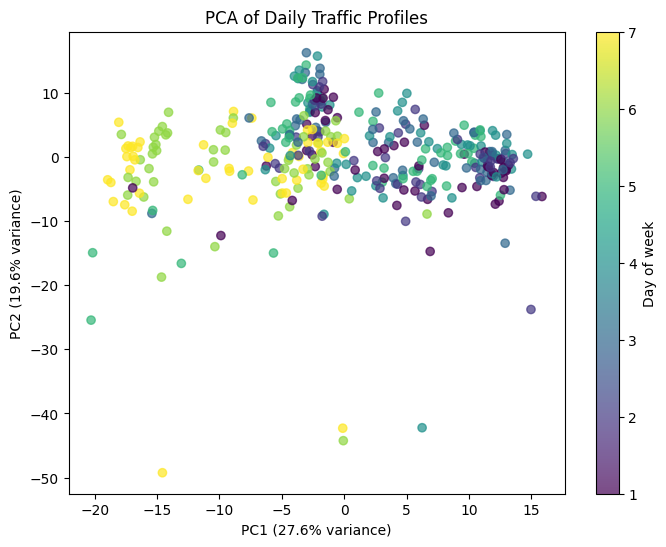

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Replace nan:s if needed
X_pca_input = np.nan_to_num(vectorized_day_dataset, nan=np.nanmean(vectorized_day_dataset))

# Standardize
X_scaled = StandardScaler().fit_transform(X_pca_input)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=day_of_week, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

ax.set_title('PCA of Daily Traffic Profiles')

plt.colorbar(scatter, ax=ax, label='Day of week')
plt.show()

# Preparing data for clustering

In [11]:
# The clustering algorithms used below do not handle nan:s directly.
# Keep only the days that are complete
valid_mask = nans_per_day == 0

vectorized_day_dataset_no_nans = vectorized_day_dataset[valid_mask, :]
days_not_nans = days[valid_mask]

X = vectorized_day_dataset_no_nans

print("Training days before nan removal:", ndays)
print("Training days used for clustering:", len(days_not_nans))
print("Clustering matrix shape:", X.shape)

Training days before NaN removal: 365
Training days used for clustering: 337
Clustering matrix shape: (337, 288)


# Internal clusering evaluation

*   Silhouette: Higher better.
*   Davies-Bouldin: Lower better.
*   Calinski-Harabasz: Higher better.


Intertia for KMeans.

BIC for GMM.

k-distance plot to guide epsilon for DBSCAN.

In [12]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

internal_results = []


def evaluate_internal(X, labels, method, parameters):
    labels = np.asarray(labels)

    # DBSCAN: -1 is NOISE, therefore exclude from internal index calculation.
    if -1 in labels:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
        noise_points = int(np.sum(labels == -1))
    else:
        X_eval = X
        labels_eval = labels
        noise_points = 0

    n_clusters_found = len(np.unique(labels_eval))

    if n_clusters_found < 2 or n_clusters_found >= len(X_eval):
        return

    internal_results.append({
        "Method": method,
        "Parameters": parameters,
        "N_clusters": n_clusters_found,
        "Noise_points": noise_points,
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Davies_Bouldin": davies_bouldin_score(X_eval, labels_eval),
        "Calinski_Harabasz": calinski_harabasz_score(X_eval, labels_eval)})

## KMeans TUNING

In [13]:
kmeans_results = []

for k in range(2, 16):
    model = KMeans(n_clusters=k, random_state=0, n_init=20)
    labels = model.fit_predict(X)

    evaluate_internal(X, labels, "KMeans", f"k={k}")

    kmeans_results.append({
        "k": k,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)})

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df

,k,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,2.368201e+08,0.307621,1.267725,174.104884
1,3,1.842887e+08,0.271584,1.349397,159.136026
2,4,1.637271e+08,0.266348,1.460342,132.996494
3,5,1.443002e+08,0.271466,1.202528,124.010495
4,6,1.312509e+08,0.236851,1.452224,115.325098
5,7,1.248773e+08,0.247820,1.448499,103.511338
6,8,1.186280e+08,0.225473,1.533518,95.590846
7,9,1.142375e+08,0.210561,1.579263,88.168393
8,10,1.104476e+08,0.191174,1.668709,82.060740
9,11,1.063245e+08,0.178876,1.724123,77.748236


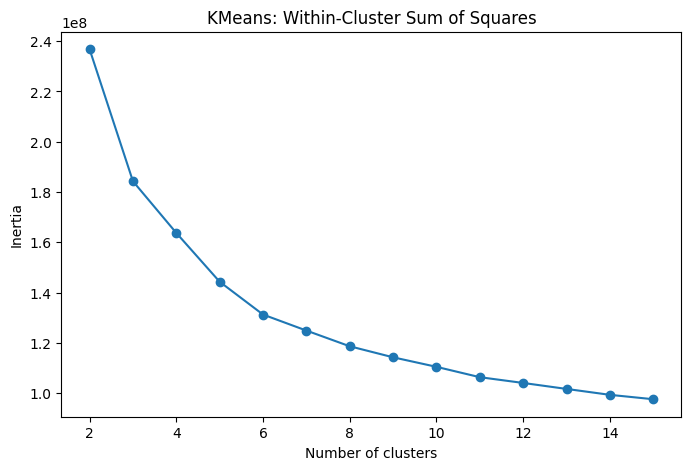

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans_results_df["k"], kmeans_results_df["Inertia"], marker="o")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")
ax.set_title("KMeans: Within-Cluster Sum of Squares")
plt.show()

Figure above shows: 5 clusters is balance between intertia elbow and cluster detail.

## Agglomerative TUNING

In [15]:
for k in range(2, 16):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )
    labels = model.fit_predict(X)
    evaluate_internal(X, labels, "Agglomerative", f"k={k}")

## GMM (Gaussian Mixture Model) TUNING

In [16]:
gmm_results = []

for k in range(2, 16):
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=0,
        n_init=5
    )
    labels = model.fit_predict(X)

    gmm_results.append({
        "N_components": k,
        "BIC": model.bic(X),
        "AIC": model.aic(X),
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    })

    evaluate_internal(X, labels, "GMM", f"components={k}")

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df

,N_components,BIC,AIC,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,5.272062e+05,207048.822645,0.307557,1.269963,174.101733
1,3,4.114933e+05,-68744.641114,0.269241,1.358789,159.134213
2,4,4.486815e+05,-191637.008856,0.229860,1.789675,122.801617
3,5,5.767842e+05,-223614.830450,0.235292,1.683207,114.489734
4,6,8.094109e+05,-151068.753011,0.235099,1.488245,114.728769
5,7,9.923278e+05,-128232.437330,0.218641,1.565549,102.869954
6,8,1.167606e+06,-113034.913705,0.213025,1.780040,93.285962
7,9,1.397721e+06,-43000.645867,0.216715,1.676599,86.615548
8,10,1.592413e+06,-8388.571186,0.188830,1.743424,81.054500
9,11,1.807828e+06,46945.917601,0.149831,1.920095,74.858249


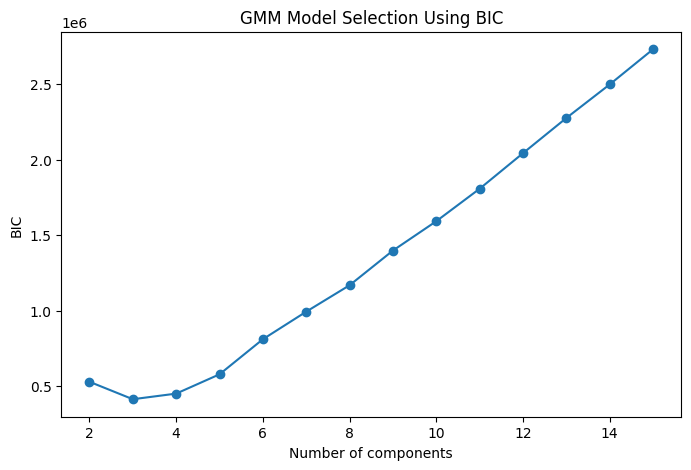

Number of GMM components with minimum BIC: 3


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gmm_results_df["N_components"], gmm_results_df["BIC"], marker="o")
ax.set_xlabel("Number of components")
ax.set_ylabel("BIC")
ax.set_title("GMM Model Selection Using BIC")
plt.show()

best_gmm_bic_k = int(
    gmm_results_df.loc[gmm_results_df["BIC"].idxmin(), "N_components"]
)
print("Number of GMM components with minimum BIC:", best_gmm_bic_k)

Figure above shows: Minimum in the figure is at 3. Optimal to choose that number of components.

## DBSCAN --> k-distance plot and parameter tuning

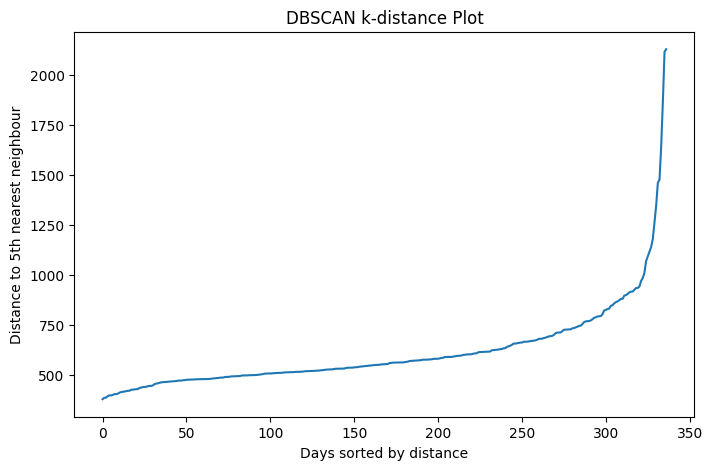

Number of dimensions: 288


In [18]:
from sklearn.neighbors import NearestNeighbors

# The lecture recommends using a sorted k-nearest-neighbour distance plot
# to guide epsilon. Here k=5 is used as a practical exploratory value.
min_samples_for_plot = 5

neighbors = NearestNeighbors(n_neighbors=min_samples_for_plot)
neighbors_fit = neighbors.fit(X)
distances, _ = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, min_samples_for_plot - 1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_distances)
ax.set_xlabel("Days sorted by distance")
ax.set_ylabel(f"Distance to {min_samples_for_plot}th nearest neighbour")
ax.set_title("DBSCAN k-distance Plot")
plt.show()

print("Number of dimensions:", X.shape[1])

In [19]:
# Based on the observed knee in the k-distance plot (~950-1050),
# test values around that region.
eps_values = [850, 900, 950, 1000, 1050, 1100]
min_samples_values = [3, 5, 7]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )
        labels = model.fit_predict(X)
        evaluate_internal(
            X,
            labels,
            "DBSCAN",
            f"eps={eps}, min_samples={min_samples}"
        )

# Comparing interval evaluation - THE RESULTS

In [20]:
internal_results_df = pd.DataFrame(internal_results)

# Full table, best Silhouette first
internal_results_df.sort_values("Silhouette", ascending=False)

,Method,Parameters,N_clusters,Noise_points,Silhouette,Davies_Bouldin,Calinski_Harabasz
43,DBSCAN,"eps=1100, min_samples=3",2,7,0.538302,0.581298,21.504942
42,DBSCAN,"eps=1050, min_samples=3",2,7,0.538302,0.581298,21.504942
0,KMeans,k=2,2,0,0.307621,1.267725,174.104884
28,GMM,components=2,2,0,0.307557,1.269963,174.101733
14,Agglomerative,k=2,2,0,0.290945,1.279138,159.821505
1,KMeans,k=3,3,0,0.271584,1.349397,159.136026
3,KMeans,k=5,5,0,0.271466,1.202528,124.010495
29,GMM,components=3,3,0,0.269241,1.358789,159.134213
15,Agglomerative,k=3,3,0,0.268112,1.313811,148.607605
2,KMeans,k=4,4,0,0.266348,1.460342,132.996494


In [21]:
non_dbscan_results = internal_results_df[
    internal_results_df["Method"] != "DBSCAN"
].copy()


def extract_cluster_number(parameter_string):
    if parameter_string.startswith("k="):
        return int(parameter_string.split("=")[1])
    if parameter_string.startswith("components="):
        return int(parameter_string.split("=")[1])
    return np.nan

non_dbscan_results["Cluster_number"] = (
    non_dbscan_results["Parameters"].apply(extract_cluster_number))

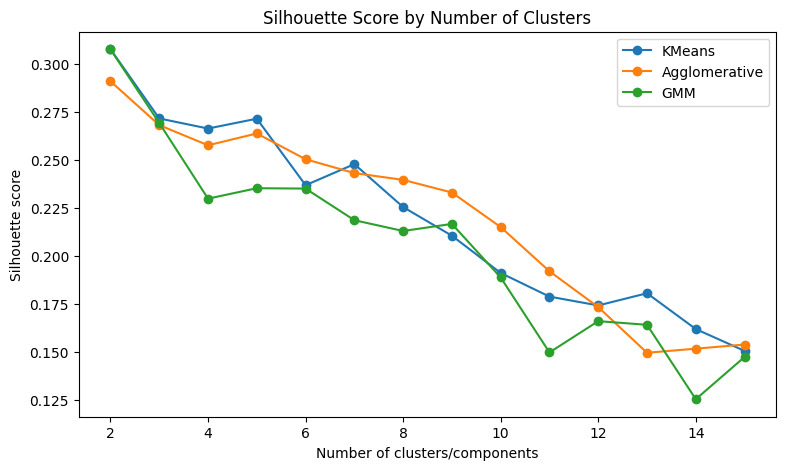

In [22]:
# Silhouette
fig, ax = plt.subplots(figsize=(9, 5))

for method in ["KMeans", "Agglomerative", "GMM"]:
    temp = non_dbscan_results[non_dbscan_results["Method"] == method]
    ax.plot(temp["Cluster_number"], temp["Silhouette"], marker="o", label=method)

ax.set_xlabel("Number of clusters/components")
ax.set_ylabel("Silhouette score")

ax.set_title("Silhouette Score by Number of Clusters")

ax.legend()
plt.show()

According to the Silhouette Score: Higher is better. Cohesion and separation are combined, measure of how well the points fit within the clusters.

Figure above shows approximately the highest value for 2-3 clusters.

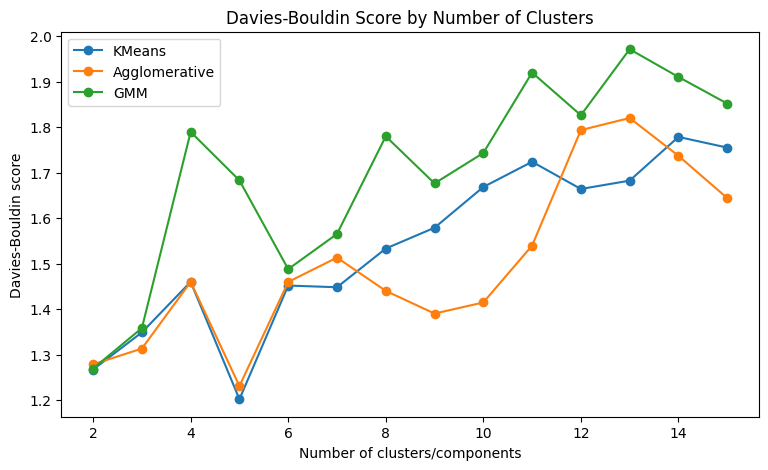

In [23]:
# Davies-Bouldin
fig, ax = plt.subplots(figsize=(9, 5))

for method in ["KMeans", "Agglomerative", "GMM"]:
    temp = non_dbscan_results[non_dbscan_results["Method"] == method]
    ax.plot(temp["Cluster_number"], temp["Davies_Bouldin"], marker="o", label=method)

ax.set_xlabel("Number of clusters/components")
ax.set_ylabel("Davies-Bouldin score")

ax.set_title("Davies-Bouldin Score by Number of Clusters")

ax.legend()
plt.show()

According to the Davis-Bouldin Score: Lower is better. Comparison between the compactness of each cluster and how separated similar clusters that are neighbors are.

Figure above shows approximately the lowest value for 5 clusters (KMeans and Agglomerative) and 3 clusters for GMM.

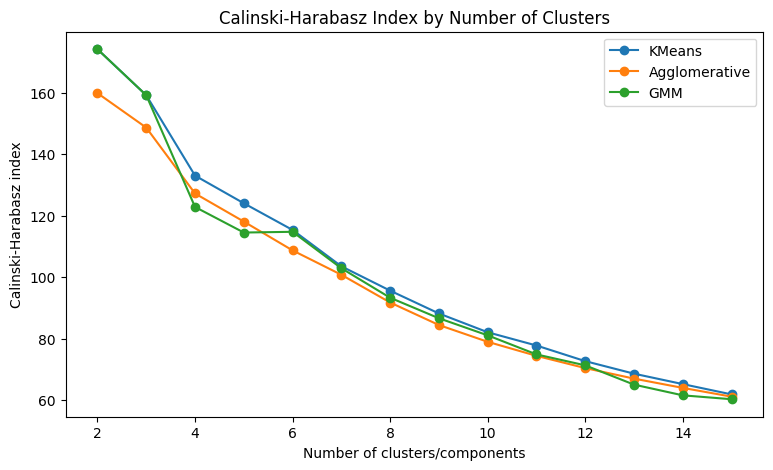

In [24]:
# Calinski-Harabasz
fig, ax = plt.subplots(figsize=(9, 5))

for method in ["KMeans", "Agglomerative", "GMM"]:
    temp = non_dbscan_results[non_dbscan_results["Method"] == method]
    ax.plot(temp["Cluster_number"], temp["Calinski_Harabasz"], marker="o", label=method)

ax.set_xlabel("Number of clusters/components")
ax.set_ylabel("Calinski-Harabasz index")

ax.set_title("Calinski-Harabasz Index by Number of Clusters")

ax.legend()
plt.show()

According to the Calinski-Harabasz index: Higher is better. Comparison between cluster distribution and the one within the cluster.

Figure above shows 2-3 clusters being optimal.

In [25]:
# Inspecting DBSCAN candidates separately because it also produces noise points
dbscan_results_df = (
    internal_results_df[internal_results_df["Method"] == "DBSCAN"]
    .sort_values("Silhouette", ascending=False)
    .reset_index(drop=True))

dbscan_results_df

,Method,Parameters,N_clusters,Noise_points,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,DBSCAN,"eps=1050, min_samples=3",2,7,0.538302,0.581298,21.504942
1,DBSCAN,"eps=1100, min_samples=3",2,7,0.538302,0.581298,21.504942


# Candidate from each clustering family




In [26]:
best_kmeans_k = 5
best_agg_k = 5
# Expecting to be 3 from the current BIC plot (See code cell 17)
best_gmm_k = best_gmm_bic_k

# Reproducible DBSCAN candidate selection for the notebook.
# Restrict to solutions with <=30% noise, then choose highest Silhouette.
max_noise_points = int(0.30 * len(X))
valid_dbscan = dbscan_results_df[
    dbscan_results_df["Noise_points"] <= max_noise_points].copy()

if len(valid_dbscan) == 0:
    raise ValueError("No tested DBSCAN setting produced <=30% noise. Expand the parameter search.")

best_dbscan_row = valid_dbscan.sort_values("Silhouette", ascending=False).iloc[0]
parameter_string = best_dbscan_row["Parameters"]
best_dbscan_eps = float(parameter_string.split(",")[0].split("=")[1])
best_dbscan_min_samples = int(parameter_string.split(",")[1].split("=")[1])

print("Selected KMeans k:", best_kmeans_k)
print("Selected Agglomerative k:", best_agg_k)
print("Selected GMM components:", best_gmm_k)
print("Selected DBSCAN eps:", best_dbscan_eps)
print("Selected DBSCAN min_samples:", best_dbscan_min_samples)
print("Selected DBSCAN noise points:", int(best_dbscan_row["Noise_points"]))
print("Selected DBSCAN clusters:", int(best_dbscan_row["N_clusters"]))

Selected KMeans k: 5
Selected Agglomerative k: 5
Selected GMM components: 3
Selected DBSCAN eps: 1050.0
Selected DBSCAN min_samples: 3
Selected DBSCAN noise points: 7
Selected DBSCAN clusters: 2


# The elected candidate for each method is fitted

In [27]:
kmeans_best = KMeans(
    n_clusters=best_kmeans_k,
    random_state=0,
    n_init=20)

labels_kmeans = kmeans_best.fit_predict(X)

agg_best = AgglomerativeClustering(
    n_clusters=best_agg_k,
    linkage="ward",
    metric="euclidean")

labels_agg = agg_best.fit_predict(X)

gmm_best = GaussianMixture(
    n_components=best_gmm_k,
    covariance_type="full",
    random_state=0,
    n_init=5)

labels_gmm = gmm_best.fit_predict(X)

dbscan_best = DBSCAN(
    eps=best_dbscan_eps,
    min_samples=best_dbscan_min_samples,
    metric="euclidean")

labels_dbscan = dbscan_best.fit_predict(X)

In [28]:
# Summary of selected clusterings, KMeans: 3, Agglomerative: 5, GMM: 3.
selected_labels = {
    "KMeans": labels_kmeans,
    "Agglomerative": labels_agg,
    "GMM": labels_gmm,
    "DBSCAN": labels_dbscan
}

for method, labels in selected_labels.items():
    unique, counts = np.unique(labels, return_counts=True)
    print("\n", method)
    for cluster_id, count in zip(unique, counts):
        if cluster_id == -1:
            print(f"Noise (-1): {count} days")
        else:
            print(f"Cluster {cluster_id}: {count} days")


 KMeans
Cluster 0: 135 days
Cluster 1: 80 days
Cluster 2: 49 days
Cluster 3: 70 days
Cluster 4: 3 days

 Agglomerative
Cluster 0: 128 days
Cluster 1: 83 days
Cluster 2: 52 days
Cluster 3: 71 days
Cluster 4: 3 days

 GMM
Cluster 0: 120 days
Cluster 1: 83 days
Cluster 2: 134 days

 DBSCAN
Noise (-1): 7 days
Cluster 0: 327 days
Cluster 1: 3 days


# Representation of day-type centroids

Capture patterns.

In [29]:
def calculate_centroids(X, labels):
    centroids = []
    cluster_ids = []

    for cluster_id in np.unique(labels):
        if cluster_id == -1:  # DBSCAN noise
            continue

        cluster_data = X[labels == cluster_id]
        centroids.append(np.mean(cluster_data, axis=0))
        cluster_ids.append(cluster_id)

    return np.array(centroids), cluster_ids


centroids_kmeans, ids_kmeans = calculate_centroids(X, labels_kmeans)
centroids_agg, ids_agg = calculate_centroids(X, labels_agg)
centroids_gmm, ids_gmm = calculate_centroids(X, labels_gmm)
centroids_dbscan, ids_dbscan = calculate_centroids(X, labels_dbscan)

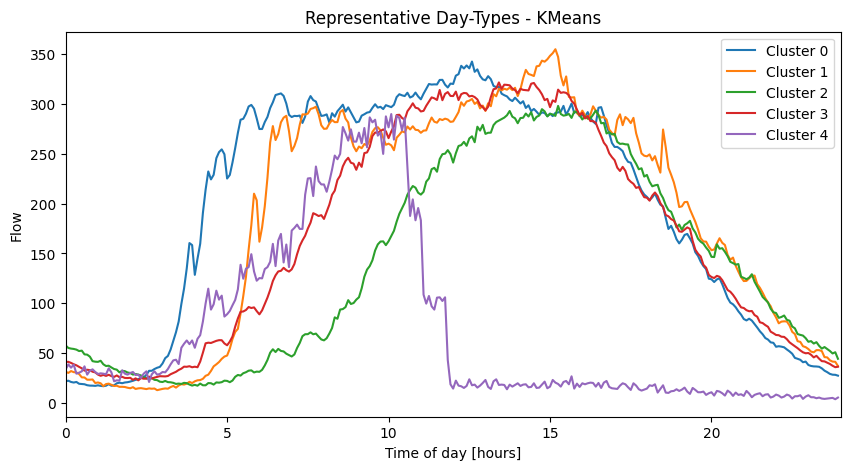

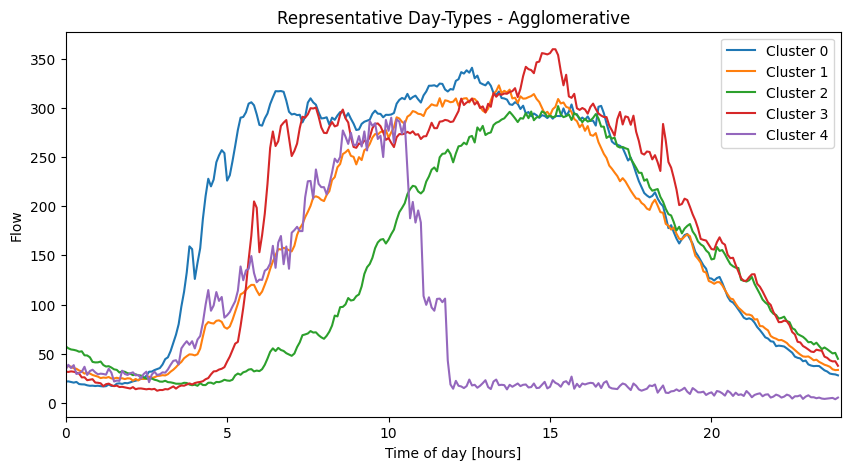

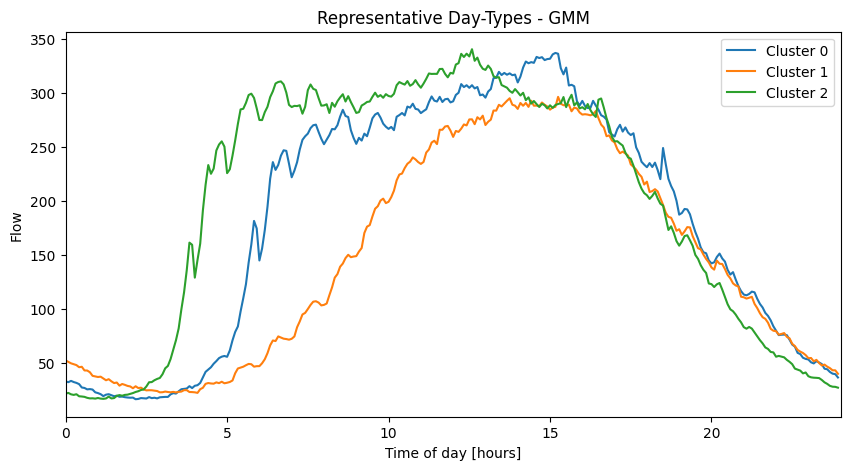

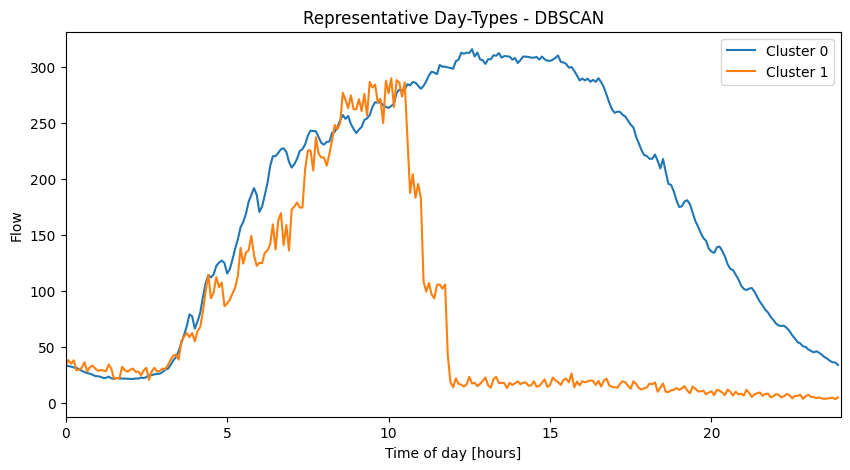

In [30]:
def plot_centroids(centroids, cluster_ids, method):
    fig, ax = plt.subplots(figsize=(10, 5))

    for centroid, cluster_id in zip(centroids, cluster_ids):
        ax.plot(x_axis_hours, centroid, label=f"Cluster {cluster_id}")

    ax.set_xlabel("Time of day [hours]")
    ax.set_ylabel("Flow")
    ax.set_title(f"Representative Day-Types - {method}")
    ax.set_xlim(0, 24)
    ax.legend()
    plt.show()


plot_centroids(centroids_kmeans, ids_kmeans, "KMeans")
plot_centroids(centroids_agg, ids_agg, "Agglomerative")
plot_centroids(centroids_gmm, ids_gmm, "GMM")
plot_centroids(centroids_dbscan, ids_dbscan, "DBSCAN")

**Figures above show**

Representative Day-Types KMeans: The graph above shows 5 different clusters. The pattern is different regarding when traffic starts increasing and then for how long the flow is high. Cluster 0 rises the earliest with a steep curve and cluster 2 the latest. Cluster 4 has the highest traffic until midday and then remains very low the rest of the day. The traffic flow is pretty representative of daily observations. The difference between the centroids represented could be due to weekend/weekday traffic.

Representative Day-Types Agglomerative: Cluster 1 and 3 corresponds to Cluster 3 and 2 if compared to KMeans. The graph also shows five representative profiles, the likeness with the KMeans graph reflects that some main structures in the data can be found with different clustering methods. This algorithm shows that the pattern is alike.  

Representative Day-Types GMM (Gaussian Mixture Model): Here, there are three representative day types. The profiles have some different chatacteristics but differ the most during the morning increase, cluster 2 rises very steep, cluster 0 increases during the morning and is also pretty steep, in contrast to cluster 1 that has a gradual development during the whole morning and almost until mid afternoon.

Representative Day-Types DBSCAN: Shows two representative day types or clusters. Cluster 0 shows an increasing morning traffic, almost uninterrupted flow and then a gradual decline from mid afternoon. Cluster 1 has a steep drop after midday and remains low after that. Explanation is that DBSCAN is density based, lower density observations are counted as outliers or noise. Number of clusters is dependent on density parameters (eps and min_samples are two of those).

# Calendar visualization of clusterings

In [31]:
from dateutil.relativedelta import relativedelta
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib import colors


def assign_colors(n_clusters, days, assignments):
    days_colors = []
    color_to_cluster = [None] * n_clusters
    style_to_cluster = [None] * n_clusters

    weekend_colors = ["#67001f", "#d6604d", "#fdae61", "#f46d43", "#d53e4f", "#9e0142", "#f768a1", "#f1c232"]
    mixed_colors = ["#4d4d4d", "#35978f", "#bababa", "#878787"]
    weekday_colors = ["#a6cee3", "#1f78b4", "#b2df8a", "#33a02c", "#cab2d6", "#6a3d9a", "#b15928", "#8dd3c7", "#bebada", "#fb8072", "#b3de69", "#bc80bd", "#fccde5", "#ccebc5", "#35978f", "#80cdc1"]

    cluster_weekdays = [0] * n_clusters
    cluster_weekends = [0] * n_clusters
    cluster_total = [0] * n_clusters

    for day, cluster_id in zip(days, assignments):
        cluster_id = int(cluster_id)
        cluster_total[cluster_id] += 1
        dt = datetime.datetime.strptime(str(day), "%Y%m%d")
        if dt.weekday() < 5:
            cluster_weekdays[cluster_id] += 1
        else:
            cluster_weekends[cluster_id] += 1

    for cluster_id in range(n_clusters):
        if cluster_total[cluster_id] == 0:
            continue

        weekend_share = cluster_weekends[cluster_id] / cluster_total[cluster_id]
        weekday_share = cluster_weekdays[cluster_id] / cluster_total[cluster_id]

        if weekend_share > 0.6:
            color_to_cluster[cluster_id] = weekend_colors.pop() if weekend_colors else "#d6604d"
            style_to_cluster[cluster_id] = ":"
        elif weekday_share > 0.6:
            color_to_cluster[cluster_id] = weekday_colors.pop(0) if weekday_colors else "#1f78b4"
            style_to_cluster[cluster_id] = "-"
        else:
            color_to_cluster[cluster_id] = mixed_colors.pop() if mixed_colors else "#4d4d4d"
            style_to_cluster[cluster_id] = ":"

    for cluster_id in assignments:
        days_colors.append(color_to_cluster[int(cluster_id)])

    return days_colors, color_to_cluster, style_to_cluster


def calmap(ax, year, data, days, assignments, n_clusters, color_to_cluster):
    ax.tick_params("x", length=0, labelsize="medium")
    ax.tick_params("y", length=0, labelsize="x-small")

    xticks, labels = [], []
    start = datetime.datetime(year, 1, 1).weekday()

    for month in range(1, 13):
        first = datetime.datetime(year, month, 1)
        last = first + relativedelta(months=1, days=-1)

        y0 = first.weekday()
        y1 = last.weekday()
        x0 = (int(first.strftime("%j")) + start - 1) // 7
        x1 = (int(last.strftime("%j")) + start - 1) // 7

        P = [
            (x0, y0), (x0, 7), (x1, 7), (x1, y1 + 1),
            (x1 + 1, y1 + 1), (x1 + 1, 0), (x0 + 1, 0), (x0 + 1, y0)]

        xticks.append(x0 + (x1 - x0 + 1) / 2)
        labels.append(first.strftime("%b"))
        ax.add_artist(Polygon(P, edgecolor="black", facecolor="None", linewidth=1, zorder=20, clip_on=False))

    ax.add_artist(Line2D([0, 53], [5, 5], linewidth=1, zorder=20, color="black", linestyle="dashed"))

    ax.set_xticks(xticks)
    ax.set_xticklabels(labels)
    ax.set_yticks(0.5 + np.arange(7))
    ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    ax.set_title(str(year), weight="semibold")

    for day, cluster_id in zip(days, assignments):
        dt = datetime.datetime.strptime(str(day), "%Y%m%d")
        if dt.year != year:
            continue
        week_number = int(dt.strftime("%W"))
        day_of_week = dt.weekday()
        data[day_of_week, week_number] = int(cluster_id)

    cmap = colors.ListedColormap(color_to_cluster)
    cmap.set_bad(color="white")
    bounds = np.arange(-0.5, n_clusters + 0.5, 1)
    norm = colors.BoundaryNorm(bounds, cmap.N)

    ax.imshow(data,
        extent=[0, 53, 0, 7],
        zorder=10,
        interpolation="nearest",
        origin="lower",
        cmap=cmap,
        norm=norm)


def make_calendar_visualization_figure(days, assignments, n_clusters, years, color_to_cluster):
    fig = plt.figure(figsize=(10, 1.8 * len(years)), dpi=100)

    for i, year in enumerate(years, start=1):
        ax = plt.subplot(len(years), 1, i, xlim=[0, 53], ylim=[0, 7], frameon=False, aspect=1)
        data = np.full((7, 53), np.nan)
        calmap(ax, int(year), data, days, assignments, n_clusters, color_to_cluster)

    plt.tight_layout()
    plt.show()

KMeans


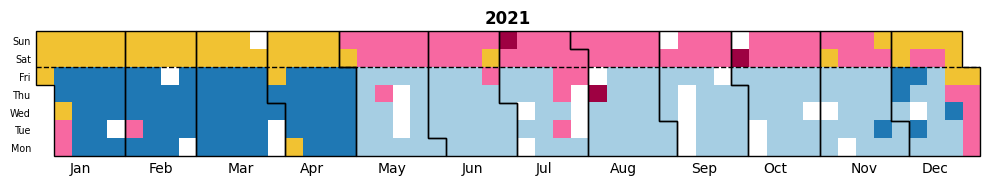

Agglomerative


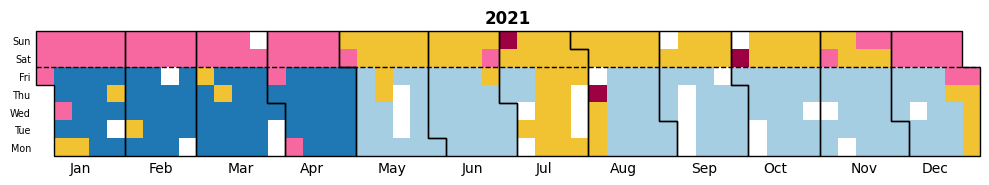

GMM


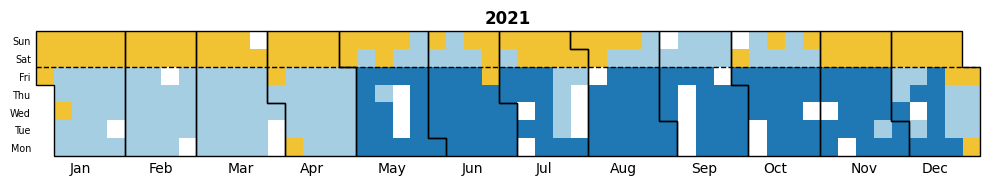

In [32]:
def show_calendar(labels, method):
    n_clusters = len(np.unique(labels))
    _, color_to_cluster, _ = assign_colors(n_clusters, days_not_nans, labels)
    print(method)
    make_calendar_visualization_figure(
        days_not_nans,
        labels,
        n_clusters,
        [2021],
        color_to_cluster)

show_calendar(labels_kmeans, "KMeans")
show_calendar(labels_agg, "Agglomerative")
show_calendar(labels_gmm, "GMM")

# External evaluation, incl dataset

In [33]:
data_eval_df = pd.read_csv(
    "evaluation_dataset_exercise_5_clustering_highway_traffic.csv",
    sep=";")
data_eval_df = data_eval_df.sort_values(["Date", "Interval_5"])

days_eval = np.unique(data_eval_df["Date"].values)
ndays_eval = len(days_eval)
day_eval_subsets_df = data_eval_df.groupby("Date")

vectorized_day_dataset_eval = np.full((ndays_eval, nintvals), np.nan)

for i, day in enumerate(days_eval):
    df_t = day_eval_subsets_df.get_group(day)
    for _, row in df_t.iterrows():
        interval = int(row["Interval_5"])
        vectorized_day_dataset_eval[i, interval] = row["flow"]

nans_per_day_eval = np.sum(np.isnan(vectorized_day_dataset_eval), axis=1)
valid_eval_mask = nans_per_day_eval == 0

X_eval = vectorized_day_dataset_eval[valid_eval_mask, :]
days_not_nans_eval = days_eval[valid_eval_mask]

print("Number of nans:", np.sum(np.isnan(vectorized_day_dataset_eval)))
print("Rate of nans:", np.mean(np.isnan(vectorized_day_dataset_eval)))
print("Number of evaluation days with missing values:", np.sum(nans_per_day_eval > 0))
print("Final number of evaluation days:", len(X_eval))

Number of NaNs: 96
Rate of NaNs: 0.004166666666666667
Number of evaluation days with missing values: 11
Final number of evaluation days: 69


# External short-term prediction evaluation

In [34]:
def evaluate_prediction(centroids, X_eval, n_past_intervals=5):
    absolute_errors = []
    percentage_errors = []

    for day in X_eval:
        for j in range(n_past_intervals - 1, len(day) - 1):
            start = j - n_past_intervals + 1
            end = j + 1

            observed_history = day[start:end]

            distances = [
                np.linalg.norm(observed_history - centroid[start:end])
                for centroid in centroids
            ]

            closest_centroid = int(np.argmin(distances))
            predicted = centroids[closest_centroid][j + 1]
            actual = day[j + 1]

            absolute_errors.append(abs(predicted - actual))
            if actual != 0:
                percentage_errors.append(abs(predicted - actual) / abs(actual))

    mae = np.mean(absolute_errors)
    mape = np.mean(percentage_errors)
    return mae, mape

In [35]:
methods_and_centroids = {
    "KMeans": centroids_kmeans,
    "Agglomerative": centroids_agg,
    "GMM": centroids_gmm,
    "DBSCAN": centroids_dbscan
}

external_results = []

for method, centroids in methods_and_centroids.items():
    mae, mape = evaluate_prediction(centroids, X_eval)
    external_results.append({
        "Method": method,
        "MAE": mae,
        "MAPE": mape
    })

external_results_df = pd.DataFrame(external_results)
external_results_df.sort_values("MAPE")

,Method,MAE,MAPE
0,KMeans,22.257361,0.198012
1,Agglomerative,22.659084,0.204265
2,GMM,25.184499,0.321155
3,DBSCAN,38.074439,0.368856


# Comparison table

In [36]:
# Internal scores for the selected candidates
selected_internal = []

selected_parameters = {
    "KMeans": f"k={best_kmeans_k}",
    "Agglomerative": f"k={best_agg_k}",
    "GMM": f"components={best_gmm_k}",
    "DBSCAN": f"eps={best_dbscan_eps}, min_samples={best_dbscan_min_samples}"}

for method, labels in selected_labels.items():
    if -1 in labels:
        mask = labels != -1
        X_t = X[mask]
        labels_t = labels[mask]
        noise_points = int(np.sum(labels == -1))
    else:
        X_t = X
        labels_t = labels
        noise_points = 0

    selected_internal.append({
        "Method": method,
        "Parameters": selected_parameters[method],
        "N_clusters": len(np.unique(labels_t)),
        "Noise_points": noise_points,
        "Silhouette": silhouette_score(X_t, labels_t),
        "Davies_Bouldin": davies_bouldin_score(X_t, labels_t),
        "Calinski_Harabasz": calinski_harabasz_score(X_t, labels_t)})

selected_internal_df = pd.DataFrame(selected_internal)

final_results = selected_internal_df.merge(external_results_df, on="Method")
final_results.sort_values("MAPE")

,Method,Parameters,N_clusters,Noise_points,Silhouette,Davies_Bouldin,Calinski_Harabasz,MAE,MAPE
0,KMeans,k=5,5,0,0.271466,1.202528,124.010495,22.257361,0.198012
1,Agglomerative,k=5,5,0,0.263778,1.231404,118.054696,22.659084,0.204265
2,GMM,components=3,3,0,0.269241,1.358789,159.134213,25.184499,0.321155
3,DBSCAN,"eps=1050.0, min_samples=3",2,7,0.538302,0.581298,21.504942,38.074439,0.368856


# PCA visualization after clustering

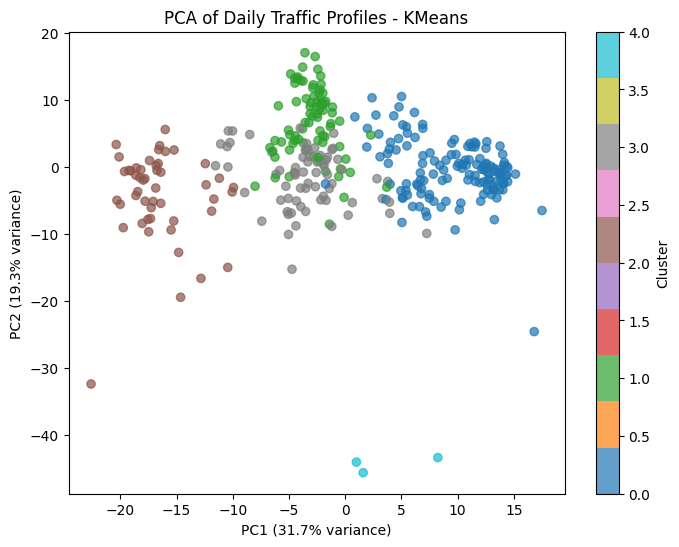

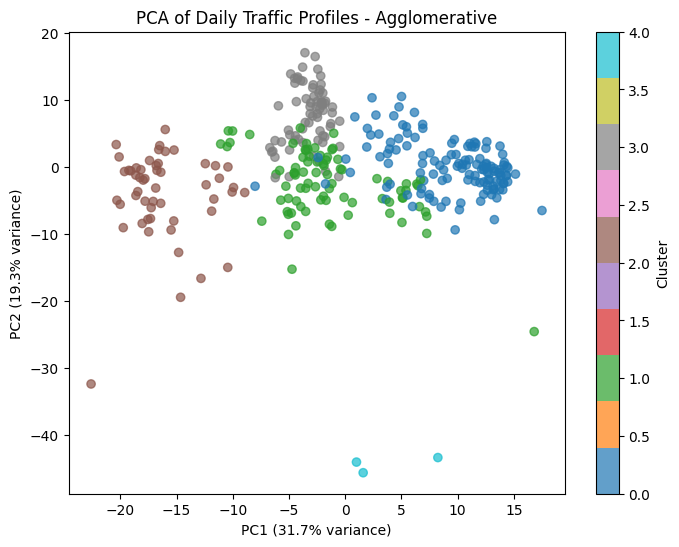

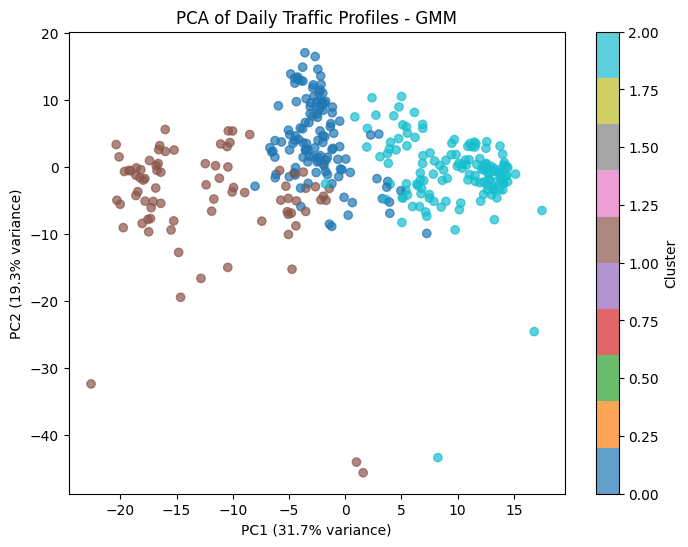

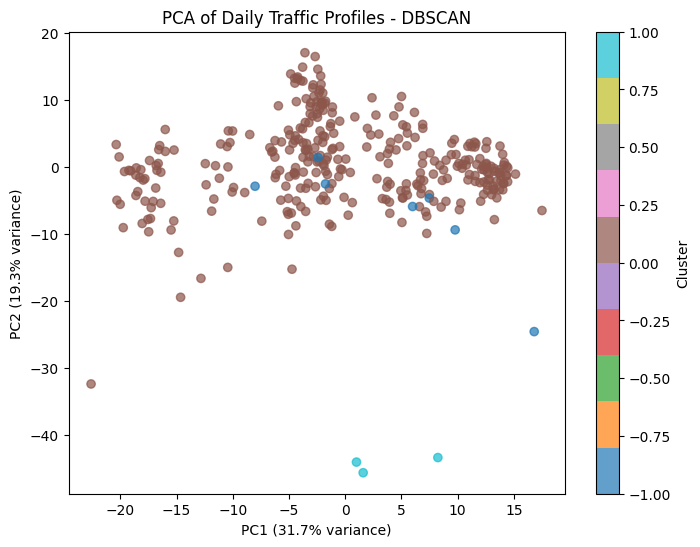

In [37]:
# Use the no-NaN clustering dataset
X_scaled_final = StandardScaler().fit_transform(X)
pca_final = PCA(n_components=2)
X_pca_final = pca_final.fit_transform(X_scaled_final)


def plot_pca_clusters(labels, method):
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        X_pca_final[:, 0],
        X_pca_final[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.7)
    ax.set_xlabel(f"PC1 ({pca_final.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_final.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title(f"PCA of Daily Traffic Profiles - {method}")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Cluster")
    plt.show()


plot_pca_clusters(labels_kmeans, "KMeans")
plot_pca_clusters(labels_agg, "Agglomerative")
plot_pca_clusters(labels_gmm, "GMM")
plot_pca_clusters(labels_dbscan, "DBSCAN")